# **UJIAN TENGAH SEMESTER**

**PREDIKSI MODERN & MACHINE LEARNING**

Nama : Kristina Claudia Bata

NIM  : 2404220049

# **EXPERIMENT 0 — DATA UNDERSTANDING & PREPARATION**

**1. Import library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

**2. Membaca dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Credit Card_PMML.csv to Credit Card_PMML.csv


In [4]:
df = pd.read_csv('Credit Card_PMML.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


**Interpretasi:**
Dataset terdiri dari 30.000 data dan 25 variabel. Data berisi karakteristik nasabah, jumlah kredit, riwayat pembayaran, tagihan, dan pembayaran. Target penelitian adalah default.payment.next.month, yaitu 0 = tidak default dan 1 = default. Variabel ID dikeluarkan dari predictor karena hanya merupakan identitas nasabah.

**3. Melihat dimensi dataset**

In [5]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 30000
Jumlah kolom: 25


Dataset terdiri dari 30.000 observasi dan 25 variabel yang mencakup karakteristik nasabah, informasi kredit, riwayat pembayaran, tagihan, pembayaran, dan target default pembayaran kartu kredit.

**4. Melihat struktur data**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Berdasarkan struktur data, dataset memiliki 30.000 observasi dan 25 variabel. Seluruh variabel memiliki 30.000 nilai non-null, sehingga tidak terdapat missing value. Dataset terdiri dari 13 variabel bertipe float64 dan 12 variabel bertipe int64. Variabel target adalah default.payment.next.month yang bertipe integer dan digunakan untuk klasifikasi default pembayaran.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Berdasarkan statistik deskriptif, dataset memiliki 30.000 data dan seluruh variabel memiliki jumlah observasi yang sama. Variabel LIMIT_BAL memiliki rata-rata sekitar Rp167.484, sedangkan usia nasabah rata-rata 35,49 tahun. Variabel PAY_0–PAY_6 memiliki nilai minimum -2 dan maksimum 8 yang menunjukkan adanya variasi status pembayaran. Nilai BILL_AMT dan PAY_AMT memiliki rentang yang cukup besar, sehingga terdapat perbedaan kemampuan pembayaran antar nasabah. Variabel target default.payment.next.month memiliki rata-rata 0,2212, yang berarti sekitar 22,12% nasabah mengalami default, sedangkan sekitar 77,88% tidak mengalami default.

**5. Mengecek missing value**

In [8]:
missing = df.isnull().sum()

print(missing)

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [9]:
print("Total missing value:", df.isnull().sum().sum())

Total missing value: 0


**Interpretasi:**
Berdasarkan pemeriksaan missing value, tidak ditemukan nilai yang hilang pada dataset. Oleh karena itu, tidak dilakukan proses imputasi dan seluruh observasi dapat digunakan dalam tahap analisis berikutnya.

**6. Mengecek duplicate**

In [10]:
print("Jumlah duplicate:", df.duplicated().sum())

Jumlah duplicate: 0


Hasil pemeriksaan menunjukkan bahwa jumlah data duplikat adalah 0, sehingga tidak terdapat baris data yang sama atau terduplikasi dalam dataset. Dengan demikian, data dapat digunakan untuk tahap analisis dan pemodelan tanpa perlu dilakukan penghapusan data duplikat.

**7. Mengecek ID**

In [11]:
print(df['ID'].nunique())
print(df['ID'].head())

30000
0    1
1    2
2    3
3    4
4    5
Name: ID, dtype: int64


ID tidak boleh digunakan sebagai predictor.

In [13]:
# Menentukan predictor (X) dan target (y)
X = df.drop(columns=['ID', 'default.payment.next.month'])
y = df['default.payment.next.month']

# Menampilkan informasi X dan y
print("=== PREDICTOR (X) ===")
print("Jumlah data dan variabel:", X.shape)
print("\nNama variabel predictor:")
print(X.columns.tolist())

print("\n=== TARGET (y) ===")
print("Jumlah data:", y.shape)
print("\nNama target:", y.name)
print("\nDistribusi target:")
print(y.value_counts())

=== PREDICTOR (X) ===
Jumlah data dan variabel: (30000, 23)

Nama variabel predictor:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

=== TARGET (y) ===
Jumlah data: (30000,)

Nama target: default.payment.next.month

Distribusi target:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


Dataset memiliki 23 variabel predictor (X) dengan 30.000 observasi, sedangkan variabel target (y) adalah default.payment.next.month. Distribusi target menunjukkan 23.364 nasabah (77,88%) tidak mengalami default dan 6.636 nasabah (22,12%) mengalami default. Data target menunjukkan adanya ketidakseimbangan kelas, sehingga evaluasi model akan lebih berfokus pada F1-score, precision, dan recall, bukan hanya accuracy.

**8. Mengecek target**

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


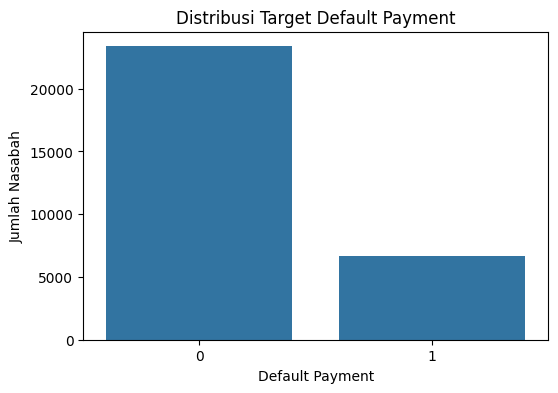

In [17]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title('Distribusi Target Default Payment')
plt.xlabel('Default Payment')
plt.ylabel('Jumlah Nasabah')

plt.show()

Berdasarkan distribusi target, sebanyak 23.364 data (77,88%) termasuk kelas 0 atau tidak mengalami default, sedangkan 6.636 data (22,12%) termasuk kelas 1 atau mengalami default. Hal ini menunjukkan bahwa dataset memiliki ketidakseimbangan kelas (class imbalance), karena jumlah nasabah yang tidak default jauh lebih banyak dibandingkan nasabah yang default. Oleh karena itu, F1-score, precision, dan recall penting digunakan sebagai metrik evaluasi selain accuracy.

**9. Mengecek nilai tidak wajar**

In [18]:
categorical_check = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

for col in categorical_check:
    print(f"\n{col}")
    print(sorted(df[col].unique()))


SEX
[np.int64(1), np.int64(2)]

EDUCATION
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

MARRIAGE
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

PAY_0
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_2
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_3
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_4
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_5
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

PAY_6
[np.int64(-2), np.int64(-1), np.int64(0), n

Hasil pemeriksaan nilai unik menunjukkan bahwa variabel SEX, EDUCATION, dan MARRIAGE memiliki kategori nilai yang terbatas dan konsisten. Sementara itu, variabel PAY_0 hingga PAY_6 memiliki nilai berkisar antara -2 hingga 8, yang menunjukkan variasi status pembayaran nasabah. Nilai -2, -1, dan 0 tidak langsung dianggap sebagai missing value, karena merupakan kode kategori/status dalam dataset. Oleh karena itu, seluruh nilai tersebut tetap dipertahankan untuk proses pemodelan.

**10. Train-Test Split**

Ini harus dilakukan sebelum preprocessing yang belajar dari data.

In [22]:
# Menentukan predictor (X) dan target (y)
X = df.drop(columns=['ID', 'default.payment.next.month'])
y = df['default.payment.next.month']

# Membagi data menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [23]:
# Menampilkan hasil pembagian data
print("=== HASIL TRAIN-TEST SPLIT ===")
print("Jumlah data awal        :", len(df))
print("Jumlah predictor        :", X.shape[1])

print("\nData Training")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nData Testing")
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)


=== HASIL TRAIN-TEST SPLIT ===
Jumlah data awal        : 30000
Jumlah predictor        : 23

Data Training
X_train : (24000, 23)
y_train : (24000,)

Data Testing
X_test  : (6000, 23)
y_test  : (6000,)


**Interpretasi:** Dataset dibagi menjadi 80% data training sebanyak 24.000 observasi dan 20% data testing sebanyak 6.000 observasi, dengan 23 variabel predictor. Data training digunakan untuk membangun dan melatih model, sedangkan data testing digunakan untuk mengukur kemampuan model pada data yang belum pernah dilihat sebelumnya. Pembagian ini dilakukan sebelum proses pemodelan untuk membantu mencegah data leakage.

In [24]:
# Menampilkan distribusi target
print("\n=== DISTRIBUSI TARGET ===")
print("\nTraining:")
print(y_train.value_counts())
print("\nTesting:")
print(y_test.value_counts())



=== DISTRIBUSI TARGET ===

Training:
default.payment.next.month
0    18691
1     5309
Name: count, dtype: int64

Testing:
default.payment.next.month
0    4673
1    1327
Name: count, dtype: int64


**Interpretasi:** Distribusi target pada data training terdiri dari 18.691 data kelas 0 dan 5.309 data kelas 1, sedangkan data testing terdiri dari 4.673 data kelas 0 dan 1.327 data kelas 1. Proporsi kedua kelas pada training dan testing relatif sama, sehingga penggunaan stratify=y berhasil mempertahankan distribusi target saat pembagian data.

In [25]:
# Menampilkan persentase target
print("\n=== PERSENTASE TARGET ===")
print("\nTraining:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting:")
print((y_test.value_counts(normalize=True) * 100).round(2))


=== PERSENTASE TARGET ===

Training:
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64

Testing:
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


**Interpretasi:** Hasil pembagian data menunjukkan bahwa data training dan testing memiliki distribusi target yang sama, yaitu 77,88% kelas 0 (tidak default) dan 22,12% kelas 1 (default). Hal ini menunjukkan bahwa proses train-test split dengan stratify=y berhasil mempertahankan proporsi masing-masing kelas, sehingga pembagian data tetap representatif terhadap dataset awal.

**Interpretasi Umum Experiment 0 — Data Understanding & Preparation**

Berdasarkan hasil Data Understanding & Preparation, dataset terdiri dari 30.000 observasi dan 25 variabel, dengan 23 variabel predictor dan 1 variabel target setelah ID dikeluarkan. Tidak ditemukan missing value maupun data duplikat, sehingga tidak diperlukan proses imputasi atau penghapusan data duplikat. Pemeriksaan nilai unik menunjukkan bahwa variabel kategorikal dan status pembayaran memiliki nilai yang bervariasi dan tetap dipertahankan karena merupakan bagian dari informasi data. Distribusi target menunjukkan 77,88% nasabah tidak mengalami default dan 22,12% mengalami default, sehingga terdapat ketidakseimbangan kelas. Dataset kemudian dibagi menjadi 80% data training (24.000) dan 20% data testing (6.000) menggunakan stratifikasi, sehingga proporsi target pada kedua data tetap sama. Dengan demikian, data telah siap digunakan untuk tahap pemodelan pada Experiment 1, dengan tetap memperhatikan penggunaan F1-score sebagai metrik utama.

# **EXPERIMENT 1 — BASELINE LOGISTIC REGRESSION**

**1. Logistic Regression**

In [26]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training
lr_baseline.fit(X_train, y_train)

# Prediksi
y_pred = lr_baseline.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline Logistic Regression")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Baseline Logistic Regression
Accuracy : 0.8036666666666666
Precision: 0.6630196936542669
Recall   : 0.22833458929917105
F1-score : 0.3396860986547085


**Interpretasi:** Model menghasilkan Accuracy 80,37%, tetapi Recall hanya 22,83% dan F1-score 33,97%. Artinya, model cukup baik dalam memprediksi kelas secara keseluruhan, tetapi masih banyak nasabah yang sebenarnya default namun gagal terdeteksi. Karena penelitian menggunakan F1-score sebagai metrik utama, performa baseline ini masih tergolong rendah dan perlu ditingkatkan pada eksperimen berikutnya.

**2. 5-fold Cross Validation**

In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_f1 = cross_val_score(
    lr_baseline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("CV F1-score tiap fold:", cv_f1)
print("Mean CV F1-score:", cv_f1.mean())

CV F1-score tiap fold: [0.40079893 0.33647571 0.31130064 0.34800839 0.36573759]
Mean CV F1-score: 0.3524642521329311


**Interpretasi:** Hasil 5-Fold Cross Validation menghasilkan rata-rata F1-score sebesar 0,3525. Nilai antar-fold berada pada rentang 0,3113–0,4008, yang menunjukkan performa model relatif bervariasi. Secara keseluruhan, performa Logistic Regression baseline masih tergolong rendah dalam mendeteksi kelas default, sehingga diperlukan peningkatan pada eksperimen berikutnya.

**Interpretasi Umum Experiment 1 — Baseline Logistic Regression**

Berdasarkan hasil Baseline Logistic Regression, model memperoleh Accuracy sebesar 80,37%, tetapi memiliki Precision 66,30%, Recall 22,83%, dan F1-score 33,97%. Rendahnya Recall menunjukkan bahwa model masih kurang mampu mendeteksi nasabah yang benar-benar mengalami default. Hasil 5-Fold Cross Validation juga menghasilkan rata-rata F1-score sebesar 35,25%, sehingga performa model masih tergolong rendah. Dengan demikian, Logistic Regression baseline belum optimal untuk prediksi default dan diperlukan preprocessing serta pengembangan model pada eksperimen berikutnya.

# **EXPERIMENT 2 — PREPROCESSING**

**1. Scaling**

In [30]:
StandardScaler()

# Pipeline
lr_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Training
lr_scaled.fit(X_train, y_train)

# Prediksi
y_pred_scaled = lr_scaled.predict(X_test)

# Evaluasi
accuracy_2 = accuracy_score(y_test, y_pred_scaled)
precision_2 = precision_score(y_test, y_pred_scaled)
recall_2 = recall_score(y_test, y_pred_scaled)
f1_2 = f1_score(y_test, y_pred_scaled)

print("Accuracy :", accuracy_2)
print("Precision:", precision_2)
print("Recall   :", recall_2)
print("F1-score :", f1_2)

Accuracy : 0.8076666666666666
Precision: 0.6868250539956804
Recall   : 0.23963828183873398
F1-score : 0.3553072625698324


**Interpretasi:** Model memperoleh Accuracy sebesar 80,77%, Precision 68,68%, Recall 23,96%, dan F1-score 35,53%. Hasil ini menunjukkan bahwa model cukup baik dalam prediksi secara keseluruhan, tetapi masih rendah dalam mendeteksi nasabah yang mengalami default. Nilai F1-score yang masih rendah menunjukkan bahwa performa model perlu ditingkatkan pada eksperimen berikutnya.

In [31]:
# CV
cv_f1_2 = cross_val_score(
    lr_scaled,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("CV F1-score tiap fold:", cv_f1_2)
print("Mean CV F1-score:", cv_f1_2.mean())

CV F1-score tiap fold: [0.36605891 0.37323944 0.38068966 0.36401674 0.33948864]
Mean CV F1-score: 0.3646986741176595


**Interpretasi:** Hasil 5-Fold Cross Validation menghasilkan rata-rata F1-score sebesar 0,3647 (36,47%), dengan nilai tiap fold berkisar antara 0,3395–0,3807. Hasil ini menunjukkan performa model relatif konsisten, tetapi kemampuan dalam mendeteksi kelas default masih tergolong rendah sehingga masih perlu ditingkatkan pada eksperimen berikutnya.

**Interpretasi Umum Experiment 2 — Standardisasi Data**

Pada Experiment 2, dilakukan standardisasi menggunakan StandardScaler sebelum proses Logistic Regression. Hasil pengujian menunjukkan Accuracy sebesar 80,77%, Precision 68,68%, Recall 23,96%, dan F1-score 35,53%, sedangkan rata-rata 5-Fold Cross Validation F1-score sebesar 36,47%. Dibandingkan baseline pada Experiment 1, standardisasi memberikan peningkatan kecil pada F1-score, dari 33,97% menjadi 35,53% pada data testing dan dari 35,25% menjadi 36,47% pada cross-validation. Hal ini menunjukkan bahwa standardisasi membantu Logistic Regression, tetapi peningkatannya masih terbatas sehingga diperlukan model lain yang lebih mampu menangkap pola default.

# **EXPERIMENT 3 — MODEL COMPARISON**

Saya akan bandingkan:

Logistic Regression
Decision Tree
Random Forest

In [32]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    return {
        'CV F1': cv_scores.mean(),
        'Test Accuracy': accuracy,
        'Test Precision': precision,
        'Test Recall': recall,
        'Test F1': f1
    }

**1. Logistic Regression**

In [33]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

**2. Decision Tree**

In [35]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

**3.Random Forest**

In [34]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

**4. Evaluasi**

In [36]:
results = []

models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

for name, model in models.items():

    result = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    result['Model'] = name
    results.append(result)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        'Model',
        'CV F1',
        'Test Accuracy',
        'Test Precision',
        'Test Recall',
        'Test F1'
    ]
]

results_df

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.364699,0.807667,0.686825,0.239638,0.355307
1,Decision Tree,0.402027,0.714500,0.369418,0.411454,0.389305
2,Random Forest,0.480764,0.812000,0.632490,0.357950,0.457170


**Interpretasi Umum Experiment 3 — Perbandingan Model**

Pada Experiment 3, dilakukan perbandingan **Logistic Regression, Decision Tree, dan Random Forest**. Berdasarkan hasil evaluasi, **Random Forest memberikan performa terbaik** dengan **CV F1 sebesar 0,4808** dan **Test F1 sebesar 0,4572**, lebih tinggi dibandingkan Decision Tree (0,3893) dan Logistic Regression (0,3553). Random Forest juga memiliki **Test Accuracy tertinggi sebesar 81,20%**. Sementara itu, Decision Tree memiliki Recall lebih tinggi daripada Logistic Regression, tetapi Accuracy dan Precision lebih rendah. Dengan demikian, **Random Forest menjadi model terbaik pada Experiment 3 berdasarkan F1-score**, sehingga layak dipilih untuk dilanjutkan ke tahap **hyperparameter tuning pada Experiment 4**.


# **EXPERIMENT 4 — HYPERPARAMETER TUNING**

In [37]:
RandomForestClassifier()

RandomForestClassifier()

**1. Parameter yang dapat diuji**

In [41]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Training
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

GridSearchCV digunakan untuk mencari kombinasi hyperparameter terbaik pada model Random Forest berdasarkan F1-score menggunakan 5-Fold Cross Validation. Hasil best_estimator_ menunjukkan bahwa kombinasi parameter terbaik adalah RandomForestClassifier, sehingga konfigurasi tersebut dipilih sebagai model Random Forest yang akan digunakan untuk evaluasi selanjutnya.

**2. Melihat hyperparameter terbaik**

In [42]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


Hasil GridSearchCV menunjukkan bahwa kombinasi hyperparameter terbaik untuk Random Forest adalah n_estimators = 100, max_depth = None, min_samples_split = 2, dan min_samples_leaf = 1. Konfigurasi ini dipilih berdasarkan F1-score terbaik pada 5-Fold Cross Validation, sehingga digunakan sebagai konfigurasi Random Forest yang optimal untuk tahap evaluasi berikutnya,

In [43]:
# CV F1
print("Best CV F1-score:")
print(grid_search.best_score_)

Best CV F1-score:
0.48076394900112607


Hasil GridSearchCV menghasilkan Best CV F1-score sebesar 0,4808 (48,08%). Artinya, konfigurasi hyperparameter terbaik pada Random Forest mampu memberikan performa rata-rata F1-score sebesar 48,08% pada 5-Fold Cross Validation. Hasil ini menunjukkan bahwa Random Forest merupakan model yang paling baik dibandingkan model sebelumnya, meskipun performanya masih dapat ditingkatkan.

**3. Test set**

In [44]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

# Evaluasi
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Test Accuracy :", accuracy_tuned)
print("Test Precision:", precision_tuned)
print("Test Recall   :", recall_tuned)
print("Test F1-score :", f1_tuned)

Test Accuracy : 0.812
Test Precision: 0.6324900133155792
Test Recall   : 0.3579502637528259
Test F1-score : 0.4571703561116458


**Interpretasi Hasil Testing Random Forest**

Random Forest menghasilkan Accuracy sebesar 81,20%, Precision 63,25%, Recall 35,80%, dan F1-score 45,72%. Hasil ini menunjukkan bahwa model cukup baik dalam melakukan prediksi, dengan F1-score lebih tinggi dibandingkan Logistic Regression dan Decision Tree. Namun, Recall yang masih 35,80% menunjukkan bahwa model masih belum optimal dalam mendeteksi nasabah yang mengalami default.

**Interpretasi Umum Experiment 4 — Hyperparameter Tuning**

Pada Experiment 4, dilakukan hyperparameter tuning menggunakan GridSearchCV dengan 5-Fold Cross Validation untuk mencari konfigurasi Random Forest yang memberikan performa terbaik. Hasil tuning memperoleh Best CV F1-score sebesar 0,4808 (48,08%) dengan parameter terbaik n_estimators=100, max_depth=None, min_samples_split=2, dan min_samples_leaf=1. Pada data testing, model menghasilkan Accuracy 81,20%, Precision 63,25%, Recall 35,80%, dan F1-score 45,72%. Hasil ini menunjukkan bahwa konfigurasi tersebut memberikan performa yang cukup baik, tetapi kemampuan model dalam mendeteksi nasabah yang mengalami default masih perlu ditingkatkan.

# **EXPERIMENT 5 — ADVANCED MODEL**

**1. XGBoost**

In [45]:
!pip install xgboost

# Import
from xgboost import XGBClassifier

# Model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)





Hasil tersebut menunjukkan bahwa XGBoost sudah terpasang pada Google Colab, sehingga tidak perlu dilakukan instalasi ulang. Versi XGBoost yang digunakan adalah 3.4.1, beserta dependensi seperti NumPy dan SciPy. Dengan demikian, lingkungan sudah siap digunakan untuk Experiment 5 — Advanced Model menggunakan XGBoost.

**2. Training**

In [46]:
xgb_model.fit(X_train, y_train)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test)

# Test Evaluation
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1-score :", f1_xgb)

Accuracy : 0.8195
Precision: 0.6694444444444444
Recall   : 0.3632253202712886
F1-score : 0.47093307278944796


Model XGBoost menghasilkan Accuracy sebesar 81,95%, Precision 66,94%, Recall 36,32%, dan F1-score 47,09%. Hasil ini menunjukkan bahwa XGBoost memiliki performa yang cukup baik dan memberikan F1-score lebih tinggi dibandingkan Random Forest (45,72%). Dengan demikian, XGBoost menjadi model dengan performa terbaik sejauh Experiment 5 berdasarkan F1-score, meskipun kemampuan mendeteksi kelas default masih dapat ditingkatkan.

In [47]:
# CV
cv_xgb = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("CV F1 tiap fold:", cv_xgb)
print("Mean CV F1:", cv_xgb.mean())

CV F1 tiap fold: [0.48326233 0.48529412 0.472661   0.48072289 0.4685784 ]
Mean CV F1: 0.47810374640952935


Hasil 5-Fold Cross Validation XGBoost menghasilkan rata-rata F1-score sebesar 0,4781 (47,81%), dengan nilai tiap fold berkisar antara 0,4686–0,4853. Nilai yang relatif berdekatan menunjukkan bahwa performa XGBoost cukup konsisten pada setiap fold. Hasil ini juga menunjukkan bahwa XGBoost memiliki kemampuan yang cukup baik dalam mendeteksi kelas default, meskipun masih terdapat ruang untuk peningkatan.

**Interpretasi Umum Experiment 5 — Advanced Model XGBoost**

Pada Experiment 5, digunakan XGBoost sebagai model advanced untuk meningkatkan performa prediksi default. Hasil pengujian menunjukkan Accuracy sebesar 81,95%, Precision 66,94%, Recall 36,32%, dan F1-score sebesar 47,09%. Pada 5-Fold Cross Validation, XGBoost memperoleh rata-rata F1-score sebesar 47,81% dengan nilai antar-fold yang relatif konsisten.

Secara keseluruhan, XGBoost memberikan performa terbaik pada data testing berdasarkan F1-score, yaitu 47,09%, sedikit lebih tinggi dibandingkan Random Forest sebesar 45,72%. Dengan demikian, XGBoost dapat dipilih sebagai model terbaik dalam rangkaian eksperimen, meskipun kemampuan mendeteksi nasabah yang mengalami default masih dapat ditingkatkan.

# **PERBANDINGAN AKHIR**

In [49]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression Baseline',
        'Logistic Regression Preprocessed',
        'Decision Tree',
        'Random Forest',
        'Random Forest Tuned',
        'XGBoost'
    ],

    'CV F1': [
        cv_f1.mean(),
        cv_f1_2.mean(),
        results_df.loc[results_df['Model'] == 'Decision Tree', 'CV F1'].values[0],
        results_df.loc[results_df['Model'] == 'Random Forest', 'CV F1'].values[0],
        grid_search.best_score_,
        cv_xgb.mean()
    ],

    'Test Accuracy': [
        accuracy,
        accuracy_2,
        results_df.loc[results_df['Model'] == 'Decision Tree', 'Test Accuracy'].values[0],
        results_df.loc[results_df['Model'] == 'Random Forest', 'Test Accuracy'].values[0],
        accuracy_tuned,
        accuracy_xgb
    ],

    'Test Precision': [
        precision,
        precision_2,
        results_df.loc[results_df['Model'] == 'Decision Tree', 'Test Precision'].values[0],
        results_df.loc[results_df['Model'] == 'Random Forest', 'Test Precision'].values[0],
        precision_tuned,
        precision_xgb
    ],

    'Test Recall': [
        recall,
        recall_2,
        results_df.loc[results_df['Model'] == 'Decision Tree', 'Test Recall'].values[0],
        results_df.loc[results_df['Model'] == 'Random Forest', 'Test Recall'].values[0],
        recall_tuned,
        recall_xgb
    ],

    'Test F1': [
        f1,
        f1_2,
        results_df.loc[results_df['Model'] == 'Decision Tree', 'Test F1'].values[0],
        results_df.loc[results_df['Model'] == 'Random Forest', 'Test F1'].values[0],
        f1_tuned,
        f1_xgb
    ]
})

final_results

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression Baseline,0.352464,0.803667,0.663020,0.228335,0.339686
1,Logistic Regression Preprocessed,0.364699,0.807667,0.686825,0.239638,0.355307
2,Decision Tree,0.402027,0.714500,0.369418,0.411454,0.389305
3,Random Forest,0.480764,0.812000,0.632490,0.357950,0.457170
4,Random Forest Tuned,0.480764,0.812000,0.632490,0.357950,0.457170
5,XGBoost,0.478104,0.819500,0.669444,0.363225,0.470933


**Interpretasi Umum Perbandingan Seluruh Eksperimen**

Berdasarkan hasil keseluruhan eksperimen, Logistic Regression Preprocessed mengalami peningkatan dibandingkan baseline, tetapi performanya masih rendah. Decision Tree memberikan peningkatan F1-score, sedangkan Random Forest menghasilkan performa yang lebih baik dengan CV F1 sebesar 48,08% dan Test F1 sebesar 45,72%. Proses tuning Random Forest tidak menghasilkan perubahan performa karena konfigurasi terbaik yang diperoleh sama dengan konfigurasi awal.

Sementara itu, XGBoost menjadi model terbaik berdasarkan Test F1-score, yaitu 47,09%, dengan Accuracy tertinggi sebesar 81,95% dan Precision 66,94%. Meskipun CV F1 XGBoost (47,81%) sedikit lebih rendah daripada Random Forest (48,08%), performa XGBoost pada data testing lebih tinggi.

Kesimpulannya, XGBoost dipilih sebagai model terbaik untuk prediksi default pada eksperimen ini karena menghasilkan Test F1-score tertinggi sebesar 47,09%. Namun, Recall sebesar 36,32% menunjukkan bahwa model masih memiliki keterbatasan dalam mendeteksi nasabah yang benar-benar mengalami default.

# **2. Experimental Analysis**

**Pertanyaan 1 — Preprocessing**

Ya, preprocessing pada Experiment 2 memberikan peningkatan performa dibandingkan baseline. F1-score meningkat dari 33,97% menjadi 35,53%, sedangkan CV F1 meningkat dari 35,25% menjadi 36,47%. Accuracy juga meningkat dari 80,37% menjadi 80,77%, sehingga standardisasi memberikan peningkatan performa meskipun masih relatif kecil.

**Pertanyaan 2 — Model Comparison**

Model terbaik pada Experiment 3 adalah Random Forest. Random Forest memperoleh CV F1 sebesar 48,08% dan Test F1 sebesar 45,72%, lebih tinggi dibandingkan Decision Tree (38,93%) dan Logistic Regression (35,53%). Random Forest juga memperoleh Test Accuracy tertinggi sebesar 81,20%.

**Pertanyaan 3 — Hyperparameter Tuning**

Tidak, hyperparameter tuning tidak meningkatkan performa Random Forest. Sebelum dan sesudah tuning, hasilnya tetap sama, yaitu CV F1 48,08%, Test Accuracy 81,20%, dan Test F1 45,72%. Hal ini terjadi karena konfigurasi terbaik hasil GridSearchCV sama dengan konfigurasi Random Forest sebelumnya.

**Pertanyaan 4 — Advanced Model**

Ya, XGBoost memberikan performa yang lebih baik pada data testing dibandingkan model terbaik sebelumnya, yaitu Random Forest. XGBoost memperoleh Test F1 sebesar 47,09%, lebih tinggi daripada Random Forest sebesar 45,72%, serta Accuracy 81,95% dibandingkan 81,20%. Namun, CV F1 XGBoost sebesar 47,81% sedikit lebih rendah daripada Random Forest sebesar 48,08%.

**Pertanyaan 5 — Final Model**

Model final yang dipilih adalah XGBoost karena menghasilkan Test F1-score tertinggi sebesar 47,09% dan Test Accuracy tertinggi sebesar 81,95% dari seluruh model yang diuji. Meskipun CV F1-nya sedikit lebih rendah daripada Random Forest, performa XGBoost pada data testing lebih baik, sehingga berdasarkan tujuan utama penelitian yang menggunakan F1-score sebagai metrik utama, XGBoost menjadi pilihan final yang paling sesuai.